# Codenames Spymaster RL Smoke Test

This notebook exercises the current end-to-end pipeline:

1. Load the smoke-test config
2. Build the embedding store and clue vocabulary
3. Reset the goal-conditioned spymaster environment and inspect the state
4. Run the greedy spymaster baseline for one episode
5. Generate demonstration data for behavioral cloning
6. Run the SAC + HER training smoke test and print evaluation metrics


In [1]:
import json
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

from src.agents.bc_pretrain import generate_demonstrations
from src.baselines.greedy_spymaster import GreedySpymaster
from src.evaluation.evaluate_agent import evaluate_agent
from src.env.visualization import plot_board
from src.training.train_sac_her import (
    build_embedding_store,
    build_env_factory,
    load_config,
    run_training_pipeline,
)


In [2]:
config = load_config(PROJECT_ROOT / "configs" / "smoke_test.yaml")
config


{'name': 'smoke_test',
 'seed': 7,
 'data': {'board_words_path': 'data/raw/codenames_words.txt',
  'clue_words_path': 'data/raw/hints.txt'},
 'embedding': {'dim': 300,
  'use_wordnet': True,
  'max_clues': 2000,
  'min_clue_length': 3,
  'max_clue_length': 12,
  'download_nltk': False,
  'nltk_packages': ['words', 'wordnet', 'omw-1.4']},
 'env': {'rows': 5,
  'cols': 5,
  'num_friendly': 8,
  'num_opponent': 8,
  'num_neutral': 8,
  'num_assassin': 1,
  'max_turns': 9,
  'max_clue_count': 9,
  'goal_size': 3},
 'reward': {'turn_penalty': -1.0,
  'assassin_penalty': -25.0,
  'shaped_weight': 1.0},
 'bc': {'enabled': True,
  'demo_episodes': 8,
  'pretrain_epochs': 1,
  'batch_size': 32,
  'learning_rate': 0.001,
  'seed_replay_buffer': True},
 'training': {'use_her': True,
  'total_timesteps': 150,
  'learning_rate': 0.0003,
  'buffer_size': 20000,
  'learning_starts': 20,
  'batch_size': 32,
  'gamma': 0.99,
  'tau': 0.005,
  'n_sampled_goal': 4,
  'goal_selection_strategy': 'future',


Board words: ['SNOW', 'FENCE', 'SCIENTIST', 'DOG', 'VACUUM', 'QUEEN', 'PLATE', 'SPINE', 'STADIUM', 'LOG', 'LAWYER', 'ROUND', 'SHOE', 'ROBIN', 'FLUTE', 'JACK', 'SATURN', 'STICK', 'BEAR', 'GROUND', 'COURT', 'MARBLE', 'BOOM', 'DANCE', 'MISSILE']
Role counts: {'friendly': 8, 'opponent': 8, 'neutral': 8, 'assassin': 1}
Observation shape: (8252,)
Achieved goal shape: (25,)
Desired goal shape: (25,)
Number of clue candidates: 8000


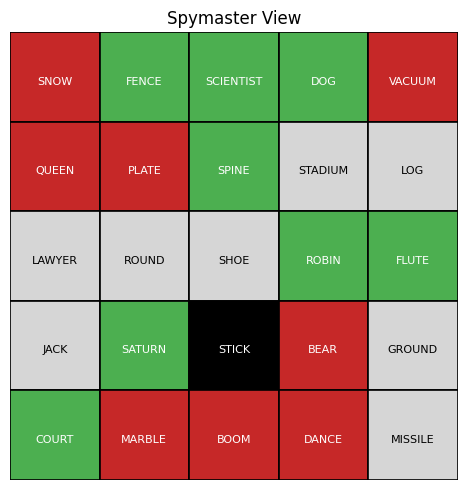

In [3]:
embedding_store = build_embedding_store(config)
env_factory = build_env_factory(config, embedding_store)
env = env_factory()
obs, info = env.reset()

print("Board words:", info["board_words"])
print("Role counts:", info["role_counts"])
print("Observation shape:", obs["observation"].shape)
print("Achieved goal shape:", obs["achieved_goal"].shape)
print("Desired goal shape:", obs["desired_goal"].shape)
print("Number of clue candidates:", len(embedding_store.clue_words))

plot_board(env.board, reveal_roles=True, title="Spymaster View")


In [4]:
greedy_agent = GreedySpymaster()
greedy_metrics = evaluate_agent(greedy_agent, env_factory=env_factory, episodes=1)
greedy_metrics


{'mean_return': -7.368869882076979,
 'mean_turns': 8.0,
 'win_rate': 1.0,
 'assassin_rate': 0.0,
 'friendly_reveal_rate': 1.0,
 'episodes': 1,
 'episode_details': [{'episode_return': -7.368869882076979,
   'turns': 8,
   'won': True,
   'assassin_hit': False,
   'friendly_revealed': 8,
   'friendly_total': 8}]}

In [5]:
demos = generate_demonstrations(
    env_factory=env_factory,
    num_episodes=config["bc"]["demo_episodes"],
    max_steps_per_episode=config["env"]["max_turns"],
)
print("Collected demonstration transitions:", len(demos))
print("Sample action vector shape:", demos[0].action.shape)
print("Sample reward:", demos[0].reward)
print("Sample clue:", demos[0].info["clue"])


Collected demonstration transitions: 64
Sample action vector shape: (301,)
Sample reward: -1.1411904692649841
Sample clue: tactor


In [6]:
results = run_training_pipeline(config)
print(json.dumps(results, indent=2))


{
  "config_name": "smoke_test",
  "demo_transitions": 64,
  "training_summary": {
    "bc_losses": [
      0.3995559513568878
    ]
  },
  "sac_metrics": {
    "mean_return": -18.03946739062667,
    "mean_turns": 5.0,
    "win_rate": 0.0,
    "assassin_rate": 0.5,
    "friendly_reveal_rate": 0.25,
    "episodes": 2,
    "episode_details": [
      {
        "episode_return": -26.179001852869987,
        "turns": 1,
        "won": false,
        "assassin_hit": true,
        "friendly_revealed": 0,
        "friendly_total": 8
      },
      {
        "episode_return": -9.89993292838335,
        "turns": 9,
        "won": false,
        "assassin_hit": false,
        "friendly_revealed": 4,
        "friendly_total": 8
      }
    ]
  },
  "greedy_metrics": {
    "mean_return": -7.611896727234125,
    "mean_turns": 8.0,
    "win_rate": 1.0,
    "assassin_rate": 0.0,
    "friendly_reveal_rate": 1.0,
    "episodes": 2,
    "episode_details": [
      {
        "episode_return": -7.5842089429